In [1]:
import os
os.chdir('pycode/')

In [2]:
from ecqf_tools import *

In [3]:
import matplotlib as mpl
from matplotlib.patches import Polygon,RegularPolygon,Rectangle,Circle
import matplotlib.pyplot as plt
import numpy as np

## Getting Started

To begin, a pair $a,p$ is chosen that satisfies:
* $p$ is prime
* $a^2 < 4p$

We're going to use precomputed data, so the first step is making sure the pair (a,p) appears in our precomputed data. 
This can be checked using the function 'ap_in_pc_data' below.

In [4]:
def ap_in_pc_data(ap:tuple[int,int])->bool:
    if ap[0]==0:
        return ap[1] in get_ssps_pc()
    else:
        return ap in get_aps_pc()

In [5]:
ap_in_pc_data((0,307)),ap_in_pc_data((0,1021))

(False, True)

In [6]:
ap_in_pc_data((12,1021))

True

## ECQF class

The class ECQFIsogenyClass takes the pair $(a,p)$ as input, loads the precomputed data, and keeps things organized so that computations don't have to be repeated. Assuming $(a,p)$ is in the precomputed list, we initialize the class with the given $a,p$.

THe class collects data about each class of lattices with CM by a root of $x^2-ax+p$/elliptic curve with that characteristic polynomial.

In [7]:
isoclass = ECQFIsogenyClass(22,1021)


### Picture

Each lattice class can be encoded into a point in the standard fundamental domain of the upper half plane mod the modular group.

We can make a picture that displays all of these points - it serves as a visual summary of the data in this class.

In [8]:
def qf_parallelogram_plot(qf:tuple[int,int,int]):
    verts = qf_parallelogram_verts(qf)
    xs = [v[0] for v in verts]
    xl, xr = min(xs),max(xs)
    ys = [v[1] for v in verts]
    ym = max(ys)
    fundom = Polygon(verts)
    fig, ax = plt.subplots()
    plt.xlim(xl-0.1,xr+0.1)
    plt.ylim(-0.1,ym+0.1)
    ax.add_patch(fundom)
    plt.gca().set_aspect('equal')
    return fig, ax

In [9]:
def uhmodgam_fd_plot(height):
    fig, ax = plt.subplots()
    ax.add_patch(mpl.patches.Rectangle((-0.5,0),width=1,height=height,facecolor=[0.7,0.7,0.7,0.5]))
    ax.add_patch(mpl.patches.Circle((0,0),1,facecolor='white',edgecolor='black'))
    plt.xlim(-1,1)
    plt.ylim(0,height)
    plt.figure(figsize=(2,height))
    plt.gca().set_aspect('equal')
    return fig, ax
    
def qfs_uhfd_plot(qflist):
    taus = np.array([abc_to_tau(qf) for qf in qflist])
    ymx = max(taus[::,1])    
    fig, ax = plt.subplots()
    ax.add_patch(mpl.patches.Rectangle((-0.5,0),width=1,height=ymx+0.1,facecolor=[0.7,0.7,0.7,0.5]))
    ax.add_patch(mpl.patches.Circle((0,0),1,facecolor='white',edgecolor='black'))
    plt.xlim(-1.1,1.1)
    plt.ylim(0,ymx+0.1)
    plt.figure(figsize=(2.2,ymx+0.1))
    ax.scatter(x = taus[::,0],y=taus[::,1])

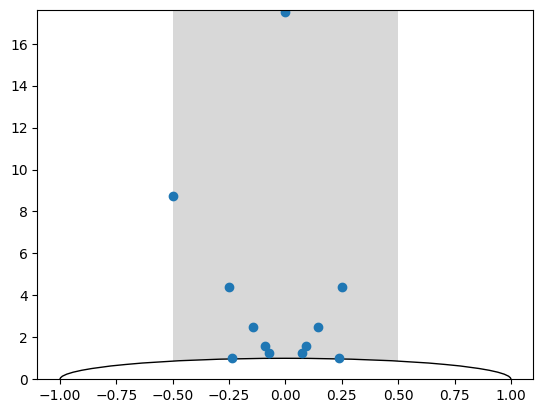

<Figure size 220x1762.14 with 0 Axes>

In [10]:
qfs_uhfd_plot(get_qfs_all(-4*307))

### Dataframe

 A summary of all available data can be obtained in the form of a pandas data_frame:

In [11]:
isoclass.ecqf_df()

,js,fg,abc
0,15,"(1019, 484)","(1, 0, 900)"
1,399,"(380, 500)","(13, -12, 72)"
2,122,"(721, 415)","(25, 0, 36)"
3,135,"(914, 718)","(13, 12, 72)"
4,217,"(438, 140)","(17, 2, 53)"
5,770,"(871, 673)","(29, -24, 36)"
6,58,"(616, 382)","(8, 4, 113)"
7,83,"(184, 990)","(9, -6, 101)"
8,334,"(60, 626)","(4, 0, 225)"
9,443,"(653, 576)","(25, 10, 37)"


## MW

In [12]:
qf0 = (isoclass.qfs_all)[-1]

In [13]:
def qf_parallelogram_verts(qf):
    tau_arr = abc_to_tau(qf)
    one_arr = np.array([1,0])
    return [0*one_arr,one_arr,one_arr+tau_arr,tau_arr]

def qf_parallelogram_plot(qf:tuple[int,int,int]):
    verts = qf_parallelogram_verts(qf)
    xs = [v[0] for v in verts]
    xl, xr = min(xs),max(xs)
    ys = [v[1] for v in verts]
    ym = max(ys)
    fundom = Polygon(verts)
    fig, ax = plt.subplots()
    plt.xlim(xl-0.1,xr+0.1)
    plt.ylim(-0.1,ym+0.1)
    ax.add_patch(fundom)
    plt.gca().set_aspect('equal')
    return fig, ax

def qf_parallelogram_plot_points(qf:tuple[int,int,int],pts:np.array):
    verts = qf_parallelogram_verts(qf)
    xs = [v[0] for v in verts]
    xl, xr = min(xs),max(xs)
    ys = [v[1] for v in verts]
    ym = max(ys)
    fundom = Polygon(verts,facecolor=[0.7,0.7,0.7,0.3])
    fig, ax = plt.subplots()
    plt.xlim(xl-0.1,xr+0.1)
    plt.ylim(-0.1,ym+0.1)
    ax.add_patch(fundom)
    ax.scatter(x = pts[::,0],y=pts[::,1])
    plt.gca().set_aspect('equal')
    return fig, ax

(<Figure size 640x480 with 1 Axes>, <Axes: >)

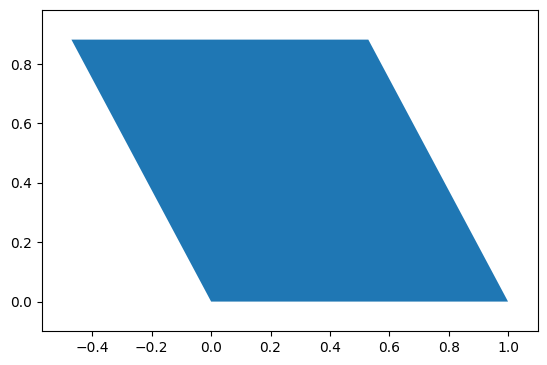

In [14]:
qf_parallelogram_plot(qf0)

In [15]:
pts0 = isoclass.qf_to_mwgr_arr_single(1,qf0)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

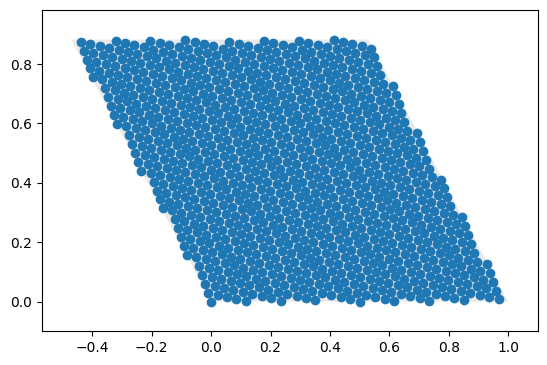

In [16]:
qf_parallelogram_plot_points(qf0,pts0)